In [37]:
# 1. Könyvtárak importálása
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE" # Ez a sor megoldja az "Intel OpenMP" könyvtár duplikációs hibáját, ami néha előfordulhat bizonyos gépeken és könyvtárkombinációknál.

# 2. EZ A KULCS: Környezeti változóként mondjuk meg a Pythonnak, hogy a háttérfolyamatokban is némítsa el ezt a specifikus figyelmeztetést
os.environ["PYTHONWARNINGS"] = "ignore:Found Intel OpenMP:RuntimeWarning"
# Biztonsági öv a fő folyamatnak is
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning, module="threadpoolctl")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, TweedieRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, StackingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures, RobustScaler, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.svm import SVR
import joblib




# 2. Fájlbeolvasás és alap statisztikák
df1 = pd.read_csv('../data/raw/CPU_benchmark_v4.csv')

# print(df1.info())

def get_stats(df, name):
    # Hiányzó értékek (NaN)
    null_counts = df.isnull().sum()
    # Nulla értékek (csak numerikus oszlopoknál releváns)
    zero_counts = (df == 0).sum()

    stats = pd.DataFrame({
        'Hiányzó (NaN)': null_counts,
        'Nulla érték (0)': zero_counts
    })
    print(f"\n--- {name} statisztikák ---")
    print(stats)
    return stats

stats1 = get_stats(df1, "CPU_benchmark_v4")

print(f"Az adathalmaz teljes mérete: {df1.shape[0]} sor és {df1.shape[1]} oszlop")
print(f"Sorok száma hiányzó értékkel: {df1.isnull().any(axis=1).sum()}")
print (f"TDP hiányzik, de Price van: {df1.isnull().any(axis=1).sum() - df1['price'].isna().sum()}")


# 3. GLOBÁLIS ADATTISZTÍTÁS (Csak egyszer fut le!)
def clean_numeric(val):
    if isinstance(val, str):
        return float(val.replace(',', ''))
    return val

# A powerPerf, price, stb. konverziója stringből floattá a teljes df_clean-en
numeric_cols = ['price', 'cpuMark', 'threadMark', 'TDP', 'powerPerf', 'cores']
for col in numeric_cols:
    if col in df1.columns:
        df1[col] = df1[col].apply(clean_numeric)

# 4. GLOBÁLIS VÁLTOZÓK (Socket csoportosítás)
top_20_sockets = df1['socket'].value_counts().nlargest(20).index
df1['socket_grouped'] = df1['socket'].apply(lambda x: x if x in top_20_sockets else 'Other')

df_inference = df1[df1['TDP'].isna() & df1['price'].notna()].copy()
output_dir = '../data/processed'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'CPU_benchmark_v4_inference.csv')
df_inference.to_csv(output_path, index=False)
print(f"Sikeresen elmentve {len(df_inference)} processzor a '{output_path}' fájlba!")

# Ezután már biztonságosan eldobhatjuk a TDP hiányzó értékeket a statisztikákhoz, hogy ne torzítsák az elemzést
df_clean = df1.dropna(subset=['TDP']).copy()
stats2 = get_stats(df_clean, "CPU_benchmark_v4")

# 5. FEATURE LISTÁK
# A) Korrelációs analízishez (itt vizsgálni akarjuk a powerPerf-et is)
corr_features = ['price', 'cpuMark', 'threadMark', 'TDP', 'powerPerf', 'cores', 'testDate', 'category']

# C) Ár (price) modellezéséhez és pótlásához (itt a célváltozók és deriváltak nincsenek bent)
features_price = ['cpuMark', 'threadMark', 'TDP', 'cores', 'testDate', 'category', 'socket_grouped']

# D) Végső Power Performance predikcióhoz (itt az ár már fontos bemeneti változó)
features_pp = ['price', 'threadMark', 'cores', 'testDate', 'category', 'socket_grouped']


--- CPU_benchmark_v4 statisztikák ---
             Hiányzó (NaN)  Nulla érték (0)
cpuName                  0                0
price                 1858                0
cpuMark                  0                0
cpuValue              1858                0
threadMark               0                0
threadValue           1858                0
TDP                    685                0
powerPerf              685                0
cores                    0                0
testDate                 0                0
socket                   0                0
category                 0                0
Az adathalmaz teljes mérete: 3825 sor és 12 oszlop
Sorok száma hiányzó értékkel: 1887
TDP hiányzik, de Price van: 29
Sikeresen elmentve 29 processzor a '../data/processed\CPU_benchmark_v4_inference.csv' fájlba!

--- CPU_benchmark_v4 statisztikák ---
                Hiányzó (NaN)  Nulla érték (0)
cpuName                     0                0
price                    1202                

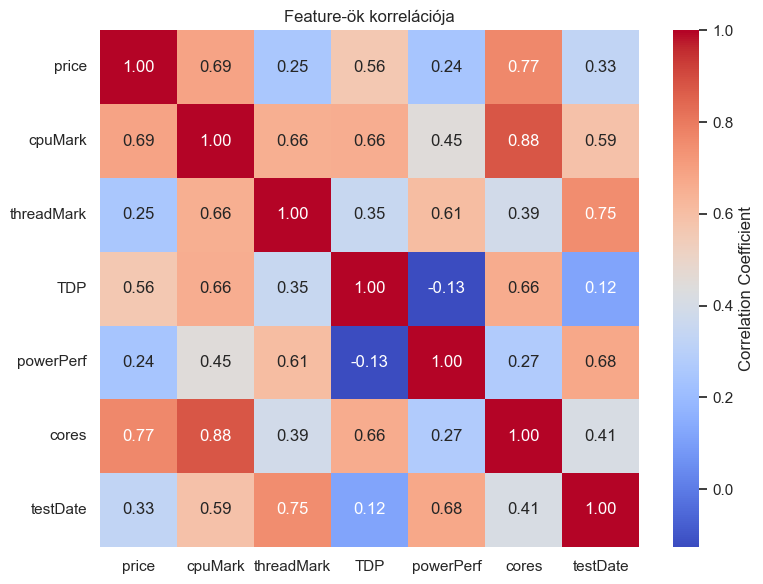

In [38]:
# === Korreláció-analízis ===
# Csak azokat az oszlopokat tartjuk meg, amik ténylegesen benne vannak a df_clean-ben
existing_features = [f for f in corr_features if f in df_clean.columns]
df_analysis_clean = df_clean[existing_features].copy()

# One-Hot Encoding alkalmazása
df_corr_analysis = pd.get_dummies(df_analysis_clean, columns=['category'] if 'category' in df_analysis_clean.columns else [], prefix='cat')

# Csak a numerikus oszlopok kiválasztása
numeric_df = df_corr_analysis.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Feature-ök korrelációja')
plt.tight_layout()
plt.show()

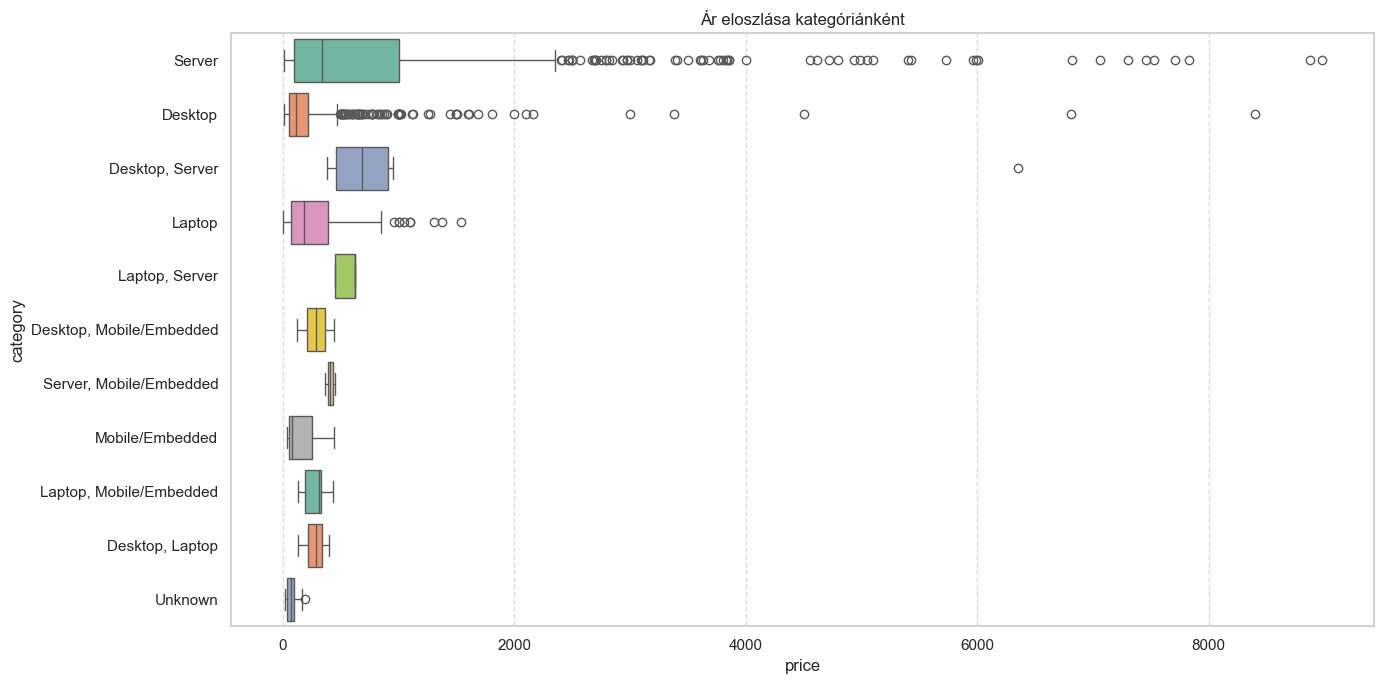

Átlagos árak kategóriánként:


category
Desktop, Server             1577.606667
Server                       876.659148
Laptop, Server               549.791429
Server, Mobile/Embedded      408.500000
Desktop, Mobile/Embedded     284.500000
Laptop, Mobile/Embedded      277.205556
Desktop, Laptop              274.497500
Laptop                       247.489302
Desktop                      224.677866
Mobile/Embedded              151.933333
Unknown                       73.625000
Name: price, dtype: float64

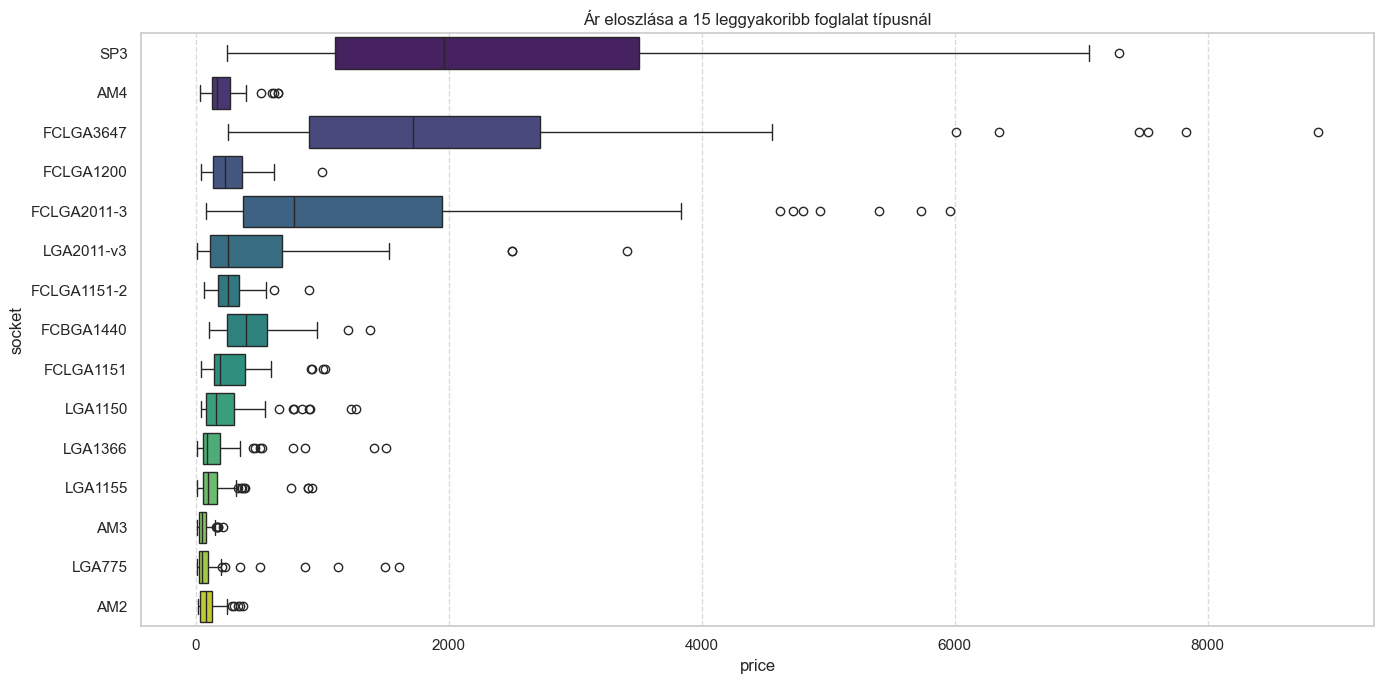

Átlagos árak a leggyakoribb socket-eknél:


socket
SP3            2467.452000
FCLGA3647      2187.002763
FCLGA2011-3    1569.967778
LGA2011-v3      595.902500
FCBGA1440       436.907308
FCLGA1151       293.376667
FCLGA1151-2     282.030349
LGA1150         266.194167
FCLGA1200       263.642688
AM4             219.615385
LGA1366         198.111167
LGA1155         153.730426
LGA775          135.242716
AM2             102.816444
AM3              60.246111
Name: price, dtype: float64

In [39]:
# Csak azokat a sorokat nézzük, ahol van ár
df_price_analysis = df_clean.dropna(subset=['price']).copy()

# 1. Ár eloszlása Category szerint
plt.figure(figsize=(14, 7))
sns.boxplot(data=df_price_analysis, x='price', y='category', hue='category', palette='Set2', legend=False)
plt.title('Ár eloszlása kategóriánként')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Átlagos árak kategóriánként:")
display(df_price_analysis.groupby('category')['price'].mean().sort_values(ascending=False))

# 2. Ár eloszlása a leggyakoribb Socket-ek szerint (Top 15)
top_sockets = df_price_analysis['socket'].value_counts().nlargest(15).index
df_top_sockets_price = df_price_analysis[df_price_analysis['socket'].isin(top_sockets)]

plt.figure(figsize=(14, 7))
sns.boxplot(data=df_top_sockets_price, x='price', y='socket', hue='socket', palette='viridis', legend=False)
plt.title('Ár eloszlása a 15 leggyakoribb foglalat típusnál')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Átlagos árak a leggyakoribb socket-eknél:")
display(df_top_sockets_price.groupby('socket')['price'].mean().sort_values(ascending=False))

In [40]:
# Új könyvtárak importálása (ezeket a notebook elejéhez is teheted)


# === Finding best Price regression ===
# Adatok előkészítése: itt a df_clean már a tisztított formátumú
df_price_base = df_clean.dropna(subset=['price'] + features_price).copy()
print(df_price_base.info())
results_list_price = []

# --- 1. Modell eredmények (eredeti adatokon + Socket) ---
y_orig_price = df_price_base["price"]
X_orig_price = pd.get_dummies(df_price_base[features_price], columns=["category", "socket_grouped"])
X_train_orig_price, X_test_orig_price, y_train_orig_price, y_test_orig_price = train_test_split(X_orig_price, y_orig_price, test_size=0.2, random_state=42)

# Kibővített modell lista (XGBoost, CatBoost és egy RobustScaler-el ellátott SVR)
models_orig_price = {
        "Linear": make_pipeline(RobustScaler(), LinearRegression()),
        "Ridge": make_pipeline(RobustScaler(), Ridge(alpha=10.0)),
        "Lasso": make_pipeline(RobustScaler(), Lasso(alpha=0.5)),
        "ElasticNet": make_pipeline(RobustScaler(), ElasticNet(alpha=0.5, l1_ratio=0.5, max_iter=2000)),
        "RandomForest_Original": RandomForestRegressor(n_estimators=100, max_depth=7, min_samples_leaf=5, random_state=42),
        "XGBoost_Original": XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, subsample=0.7, colsample_bytree=0.8, random_state=42),
        "CatBoost_Original": CatBoostRegressor(iterations=200, learning_rate=0.05, depth=6, l2_leaf_reg=5.0, random_seed=42, verbose=0),
        "SVR_Robust_Original": make_pipeline(RobustScaler(), SVR(kernel='rbf', C=10.0, gamma='scale')),
        "HistGradientBoosting_Original": HistGradientBoostingRegressor(loss='poisson', max_depth=5, l2_regularization=2.0, random_state=42),
        "PolinomialRidge_original": make_pipeline(RobustScaler(), PolynomialFeatures(degree=2), Ridge(alpha=50.0)),
        "TweedieRegression_Original": make_pipeline(RobustScaler(), TweedieRegressor(power=1.5, link='log')),
        "KNN_Robust_Original": make_pipeline(RobustScaler(), KNeighborsRegressor(n_neighbors=10)),
        "MLP_NeuralNet_Original": make_pipeline(RobustScaler(), MLPRegressor(hidden_layer_sizes=(64, 32), alpha=0.1, validation_fraction=0.1, max_iter=1000, early_stopping=True, random_state=42))
}

print("--- Modell eredmények (eredeti adatokon - Price) ---")
for name, model in models_orig_price.items():
    model.fit(X_train_orig_price, y_train_orig_price)
    y_pred = model.predict(X_test_orig_price)
    rmse = np.sqrt(mean_squared_error(y_test_orig_price, y_pred))
    mae = mean_absolute_error(y_test_orig_price, y_pred)
    r2 = r2_score(y_test_orig_price, y_pred)
    results_list_price.append({'Modell': f"{name}", 'RMSE': rmse, 'MAE': mae, 'R2 Score': r2})

# --- 2. Modell eredmények (logaritmikus transzformációval + Socket) ---
y_orig_log_price = np.log1p(y_orig_price)
X_train_orig_log_price, X_test_orig_log_price, y_train_orig_log_price, y_test_orig_log_price = train_test_split(X_orig_price, y_orig_log_price, test_size=0.2, random_state=42)

# Ugyanezek a modellek bevetése a logaritmizált célváltozón is
models_log_orig_price = {
    "Linear_log": make_pipeline(RobustScaler(), LinearRegression()),
    "Ridge_log": make_pipeline(RobustScaler(), Ridge(alpha=10.0)),
    "Lasso_log": make_pipeline(RobustScaler(), Lasso(alpha=0.5)),
    "ElasticNet_log": make_pipeline(RobustScaler(), ElasticNet(alpha=0.5, l1_ratio=0.5, max_iter=2000)),
    "RandomForest_log": RandomForestRegressor(n_estimators=100, max_depth=7, min_samples_leaf=5, random_state=42),
    "XGBoost_log": XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, subsample=0.7, colsample_bytree=0.8, random_state=42),
    "CatBoost_log": CatBoostRegressor(iterations=200, learning_rate=0.05, depth=6, l2_leaf_reg=5.0, random_seed=42, verbose=0),
    "SVR_Robust_log": make_pipeline(RobustScaler(), SVR(kernel='rbf', C=10.0, gamma='scale')),
    "HistGradientBoosting_log": HistGradientBoostingRegressor(loss='poisson', max_depth=5, l2_regularization=2.0, random_state=42),
    "PolinomialRidge_log": make_pipeline(RobustScaler(), PolynomialFeatures(degree=2), Ridge(alpha=50.0)),
    "KNN_Robust_log": make_pipeline(RobustScaler(), KNeighborsRegressor(n_neighbors=10)),
    "MLP_NeuralNet_log": make_pipeline(RobustScaler(), MLPRegressor(hidden_layer_sizes=(64, 32), alpha=0.1, validation_fraction=0.1, max_iter=1000, early_stopping=True, random_state=42))
}

print("\n--- Modell eredmények (log transzformáció - Price) ---")
for name, model in models_log_orig_price.items():
    model.fit(X_train_orig_log_price, y_train_orig_log_price)
    y_pred_log = model.predict(X_test_orig_log_price)
    y_pred = np.expm1(y_pred_log)
    rmse = np.sqrt(mean_squared_error(y_test_orig_price, y_pred))
    mae = mean_absolute_error(y_test_orig_price, y_pred)
    r2 = r2_score(y_test_orig_price, y_pred)
    results_list_price.append({'Modell': f"{name}", 'RMSE': rmse, 'MAE': mae, 'R2 Score': r2})

# --- 3. Modell eredmények (outlierek kezelése IQR-rel) ---
Q1_price = df_price_base['price'].quantile(0.25)
Q3_price = df_price_base['price'].quantile(0.75)
IQR_price = Q3_price - Q1_price
lower_bound_price = Q1_price - 1.5 * IQR_price
upper_bound_price = Q3_price + 1.5 * IQR_price

df_filtered_price = df_price_base[(df_price_base['price'] >= lower_bound_price) & (df_price_base['price'] <= upper_bound_price)].copy()

y_filt_price = df_filtered_price["price"]
X_filt_price = pd.get_dummies(df_filtered_price[features_price], columns=["category", "socket_grouped"])
X_train_filt_price, X_test_filt_price, y_train_filt_price, y_test_filt_price = train_test_split(X_filt_price, y_filt_price, test_size=0.2, random_state=42)

models_filtered_price = {
    "Linear_IQR": LinearRegression(),
    "RandomForest_IQR": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost_IQR": XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42)
}

print("\n--- Modell eredmények (outlierek kezelése IQR-rel - Price) ---")
for name, model in models_filtered_price.items():
    model.fit(X_train_filt_price, y_train_filt_price)
    y_pred_filt = model.predict(X_test_filt_price)
    rmse_filt = np.sqrt(mean_squared_error(y_test_filt_price, y_pred_filt))
    mae_filt = mean_absolute_error(y_test_filt_price, y_pred_filt)
    r2_filt = r2_score(y_test_filt_price, y_pred_filt)
    results_list_price.append({'Modell': f"{name}", 'RMSE': rmse_filt, 'MAE': mae_filt, 'R2 Score': r2_filt})

# Eredmények összegzése
comparison_df_price = pd.DataFrame(results_list_price).sort_values(by="R2 Score", ascending=False)
display(comparison_df_price)

<class 'pandas.DataFrame'>
Index: 1938 entries, 1 to 3747
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   cpuName         1938 non-null   str    
 1   price           1938 non-null   float64
 2   cpuMark         1938 non-null   int64  
 3   cpuValue        1938 non-null   float64
 4   threadMark      1938 non-null   int64  
 5   threadValue     1938 non-null   float64
 6   TDP             1938 non-null   float64
 7   powerPerf       1938 non-null   float64
 8   cores           1938 non-null   int64  
 9   testDate        1938 non-null   int64  
 10  socket          1938 non-null   str    
 11  category        1938 non-null   str    
 12  socket_grouped  1938 non-null   str    
dtypes: float64(5), int64(4), str(4)
memory usage: 300.7 KB
None
--- Modell eredmények (eredeti adatokon - Price) ---

--- Modell eredmények (log transzformáció - Price) ---

--- Modell eredmények (outlierek kezelése IQR-rel - Price) 

,Modell,RMSE,MAE,R2 Score
27,XGBoost_IQR,117.145572,79.482182,0.620447
26,RandomForest_IQR,119.342221,80.809237,0.606080
17,RandomForest_log,519.562711,190.532848,0.551396
12,MLP_NeuralNet_Original,519.884258,227.828509,0.550840
10,TweedieRegression_Original,525.856850,224.078080,0.540461
23,KNN_Robust_log,527.315973,191.062491,0.537907
9,PolinomialRidge_original,528.188227,231.632873,0.536377
11,KNN_Robust_Original,528.777931,218.660263,0.535341
19,CatBoost_log,535.488343,198.251238,0.523473
21,HistGradientBoosting_log,535.499402,198.582279,0.523453


In [41]:
# === 2. LÉPCSŐ: Price Predikciós Modell ===

# 1. TANÍTÁS: Szigorúan az eredeti, valós Price-szal ÉS valós TDP-vel rendelkező adatokon!
# Itt df_clean-et használunk, NEM a df_cascade-et!
df_price_train = df_clean.dropna(subset=['price'] + features_price).copy()

# # Logaritmizáljuk az árat!
# y_price_train_log = np.log1p(df_price_train['price'])
# X_price_train = pd.get_dummies(df_price_train[features_price], columns=['category', 'socket_grouped'])

# # Price Modell betanítása a tiszta adatokon
# price_model = RandomForestRegressor(n_estimators=100, max_depth=7, min_samples_leaf=5, random_state=42)
# price_model.fit(X_price_train, y_price_train_log)

Q1_price = df_price_train['price'].quantile(0.25)
Q3_price = df_price_train['price'].quantile(0.75)
IQR_price = Q3_price - Q1_price
lower_bound_price = Q1_price - 1.5 * IQR_price
upper_bound_price = Q3_price + 1.5 * IQR_price

df_filtered_price_train = df_price_train[(df_price_train['price'] >= lower_bound_price) & (df_price_train['price'] <= upper_bound_price)].copy()

y_filt_price_train = df_filtered_price_train["price"]
X_filt_price_train = pd.get_dummies(df_filtered_price_train[features_price], columns=["category", "socket_grouped"])

price_model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, subsample=0.7, colsample_bytree=0.8, random_state=42)
price_model.fit(X_filt_price_train, np.log1p(y_filt_price_train))


df_cascade = df_clean.copy()
# 2. PÓTLÁS (Imputation): Ahol az eredeti adatbázisban (df_cascade) hiányzott az ár.
missing_price_mask = df_cascade['price'].isnull()
df_missing_price = df_cascade[missing_price_mask].copy()

if not df_missing_price.empty:
    X_missing_price = pd.get_dummies(df_missing_price[features_price], columns=['category', 'socket_grouped'])
    X_missing_price = X_missing_price.reindex(columns=X_filt_price_train.columns, fill_value=0)
    
    # Becsült Árak beírása a cascade adatbázisba
    df_cascade.loc[missing_price_mask, 'price'] = np.round(np.expm1(price_model.predict(X_missing_price)), 2)
    df_cascade['price_is_imputed'] = missing_price_mask.astype(int)

# Opcionális: Származtatott értékek (cpuValue, threadValue) újraszámolása a már teli adatbázisban
df_cascade['cpuValue'] = df_cascade['cpuMark'] / df_cascade['price']
df_cascade['threadValue'] = df_cascade['threadMark'] / df_cascade['price']

print(f"2. LÉPCSŐ KÉSZ: Hiányzó Price értékek pótolva {missing_price_mask.sum()} sorban.")

df_cascade.to_csv('../data/processed/CPU_benchmark_v4_price_imputed.csv', index=False)
print('Kiegészített adathalmaz elmentve!')

2. LÉPCSŐ KÉSZ: Hiányzó Price értékek pótolva 1202 sorban.
Kiegészített adathalmaz elmentve!


In [42]:
# === KÍSÉRLET: Tanítás és kiértékelés KIZÁRÓLAG a valós (nem imputált) áras sorokon ===

# 1. Csak azokat a sorokat tartjuk meg a df_clean-ből, ahol az ár és a powerPerf is eredetileg létezett
df_pure_gold = df_clean.dropna(subset=['price', 'powerPerf'] + features_pp).copy()

print(f"Szigorúan valós áras sorok száma a kísérletben: {len(df_pure_gold)} sor")

# 2. X és y előkészítése (One-Hot Encoding a kategorikus változókra)
y_pure = df_pure_gold['powerPerf']
X_pure = pd.get_dummies(df_pure_gold[features_pp], columns=['category', 'socket_grouped'])

# 3. Train-Test Split (szigorúan 80-20% arányban, ugyanazzal a random_state-tel a tiszta összehasonlításhoz)
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_pure, y_pure, test_size=0.2, random_state=42
)

# 4. A két fő modelled inicializálása az általad megadott paraméterekkel
pure_xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, subsample=0.7, colsample_bytree=0.8, random_state=42)
pure_hgb = HistGradientBoostingRegressor(loss='poisson', max_depth=5, l2_regularization=2.0, random_state=42)

# 5. Tanítás és kiértékelés
print("\n--- METRIKÁK (Imputáció nélkül, csak a valós adatokon) ---")
for name, model in [("XGBoost (Pure)", pure_xgb), ("HistGradientBoosting (Pure)", pure_hgb)]:
    model.fit(X_train_p, y_train_p)
    y_pred_p = model.predict(X_test_p)
    
    rmse_p = np.sqrt(mean_squared_error(y_test_p, y_pred_p))
    mae_p = mean_absolute_error(y_test_p, y_pred_p)
    r2_p = r2_score(y_test_p, y_pred_p)
    
    print(f"\nModell: {name}")
    print(f"  RMSE:     {rmse_p:.4f}")
    print(f"  MAE:      {mae_p:.4f}")
    print(f"  R2 Score: {r2_p:.4f}")

# === KÍSÉRLET: Tanítás és kiértékelés imputált áras sorokon ===
df_price_imputed = df_cascade.dropna(subset=['powerPerf'] + features_pp).copy()

print(f"\nSorok száma a kísérletben (imputált árak is): {len(df_price_imputed)} sor")

# 2. X és y előkészítése (One-Hot Encoding a kategorikus változókra)
y_pi = df_price_imputed['powerPerf']
X_pi = pd.get_dummies(df_price_imputed[features_pp], columns=['category', 'socket_grouped'])

# 3. Train-Test Split (szigorúan 80-20% arányban, ugyanazzal a random_state-tel a tiszta összehasonlításhoz)
X_train_pi, X_test_pi, y_train_pi, y_test_pi = train_test_split(
    X_pi, y_pi, test_size=0.2, random_state=42
)

# 4. A két fő modelled inicializálása az általad megadott paraméterekkel
pi_xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, subsample=0.7, colsample_bytree=0.8, random_state=42)
pi_hgb = HistGradientBoostingRegressor(loss='poisson', max_depth=5, l2_regularization=2.0, random_state=42)

# 5. Tanítás és kiértékelés
print("\n--- METRIKÁK (Imputációval) ---")
for name, model in [("XGBoost (Imputált)", pi_xgb), ("HistGradientBoosting (Imputált)", pi_hgb)]:
    model.fit(X_train_pi, y_train_pi)
    y_pred_pi = model.predict(X_test_pi)
    
    rmse_pi = np.sqrt(mean_squared_error(y_test_pi, y_pred_pi))
    mae_pi = mean_absolute_error(y_test_pi, y_pred_pi)
    r2_pi = r2_score(y_test_pi, y_pred_pi)
    
    print(f"\nModell: {name}")
    print(f"  RMSE:     {rmse_pi:.4f}")
    print(f"  MAE:      {mae_pi:.4f}")
    print(f"  R2 Score: {r2_pi:.4f}")


Szigorúan valós áras sorok száma a kísérletben: 1938 sor

--- METRIKÁK (Imputáció nélkül, csak a valós adatokon) ---

Modell: XGBoost (Pure)
  RMSE:     53.4383
  MAE:      26.4610
  R2 Score: 0.8145

Modell: HistGradientBoosting (Pure)
  RMSE:     55.8166
  MAE:      28.6246
  R2 Score: 0.7976

Sorok száma a kísérletben (imputált árak is): 3140 sor

--- METRIKÁK (Imputációval) ---

Modell: XGBoost (Imputált)
  RMSE:     78.6206
  MAE:      37.3489
  R2 Score: 0.7694

Modell: HistGradientBoosting (Imputált)
  RMSE:     76.6492
  MAE:      36.7580
  R2 Score: 0.7808


In [51]:
# === Finding best Power Performance regression ===
from sklearn.metrics import (
    mean_squared_error, 
    mean_absolute_error, 
    r2_score,
    mean_absolute_percentage_error,  # MAPE
    mean_squared_log_error,          # MSLE
    median_absolute_error,           # MedAE
    max_error                        # Max error
)
# Adatok előkészítése: A már imputált (árral kiegészített) adatbázist használjuk
# Csak azokat a sorokat nézzük, ahol a powerPerf és a price NEM hiányzott (gold standard tanítóhalmaz)

df_pp_base = df_clean.dropna(subset=['price', 'powerPerf'] + features_pp).copy()
# print(df_pp_base.info())
results_list_pp = []

# Itt a features_pp globális listát használjuk (amiben benne van a pótolt price is!)
y_orig_pp = df_pp_base["powerPerf"]
X_orig_pp = pd.get_dummies(df_pp_base[features_pp], columns=["category", "socket_grouped"])

# --- 1. Modell eredmények (eredeti adatokon) ---
X_train_orig_pp, X_test_orig_pp, y_train_orig_pp, y_test_orig_pp = train_test_split(X_orig_pp, y_orig_pp, test_size=0.2, random_state=42)

base_estimators1 = [
    ('xgb', XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, subsample=0.7, colsample_bytree=0.8, random_state=42)),
    ('hgb', HistGradientBoostingRegressor(loss='poisson', max_depth=5, l2_regularization=2.0, random_state=42)),
    # más logika: KNN és SVR ( RobustScalerrel)
    ('knn', make_pipeline(RobustScaler(), KNeighborsRegressor(n_neighbors=10))),
    ('svr', make_pipeline(RobustScaler(), SVR(kernel='rbf', C=10.0, gamma='scale')))
]
base_estimators2 = [
    ('xgb', XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, subsample=0.7, colsample_bytree=0.8, random_state=42)),
    ('hgb', HistGradientBoostingRegressor(loss='poisson', max_depth=5, l2_regularization=2.0, random_state=42)),
    
    # RF helyett egy teljesen más logika: KNN (a RobustScaler kötelező elé!)
    ('knn', make_pipeline(RobustScaler(), KNeighborsRegressor(n_neighbors=10))),
    
    ('xgb_log', TransformedTargetRegressor(
        regressor=XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, subsample=0.7, colsample_bytree=0.8, random_state=42),
        func=np.log1p, 
        inverse_func=np.expm1
    )),
]
def stacking_model(base_estimators):
    return StackingRegressor(
        estimators=base_estimators,
        final_estimator=ElasticNet(alpha=0.05, l1_ratio=0.5), # Meta-modell csere Lasso-ra, hogy kiszűrje a gyenge prediktorokat
        cv=5,
        n_jobs=-1, # Hogy mindegyik CPU magot használja, gyorsabb legyen a futás
        passthrough=True # A meta-modell látja az eredeti oszlopokat is
    )

def stacking_model2(base_estimators):
    return StackingRegressor(
        estimators=base_estimators,
        final_estimator=RandomForestRegressor(n_estimators=50, max_depth=3, random_state=42), # Meta-modell csere RF-re, hogy komplexebb mintázatokat is megtanuljon
        cv=5,
        n_jobs=-1,
        passthrough=True
    )

models_orig_pp = {
    "Linear": make_pipeline(RobustScaler(), LinearRegression()),
    "Ridge": make_pipeline(RobustScaler(), Ridge(alpha=10.0)),
    "Lasso": make_pipeline(RobustScaler(), Lasso(alpha=0.5)),
    "ElasticNet": make_pipeline(RobustScaler(), ElasticNet(alpha=0.5, l1_ratio=0.5, max_iter=2000)),
    "RandomForest_Original": RandomForestRegressor(n_estimators=100, max_depth=7, min_samples_leaf=5, random_state=42),
    "XGBoost_Original": XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, subsample=0.7, colsample_bytree=0.8, random_state=42),
    "CatBoost_Original": CatBoostRegressor(iterations=200, learning_rate=0.05, depth=6, l2_leaf_reg=5.0, random_seed=42, verbose=0),
    "SVR_Robust_Original": make_pipeline(RobustScaler(), SVR(kernel='rbf', C=10.0, gamma='scale')),
    "HistGradientBoosting_Original": HistGradientBoostingRegressor(loss='poisson', max_depth=5, l2_regularization=2.0, random_state=42),
    "PolinomialRidge_original": make_pipeline(RobustScaler(), PolynomialFeatures(degree=2), Ridge(alpha=50.0)),
    "TweedieRegression_Original": make_pipeline(RobustScaler(), TweedieRegressor(power=1.5, link='log')),
    "KNN_Robust_Original": make_pipeline(RobustScaler(), KNeighborsRegressor(n_neighbors=10)),
    # "Stacking1_Original": stacking_model(base_estimators1),
    # "Stacking2_Original": stacking_model(base_estimators2),
    # "Stacking3_Original": stacking_model2(base_estimators1),
    # "Stacking4_Original": stacking_model2(base_estimators2),
    "MLP_NeuralNet_Original": make_pipeline(RobustScaler(), MLPRegressor(hidden_layer_sizes=(64, 32), alpha=0.1, validation_fraction=0.1, max_iter=500, early_stopping=True, random_state=42))
}

print("--- Modell eredmények (eredeti adatokon - PowerPerf) ---")
for name, model in models_orig_pp.items():
    model.fit(X_train_orig_pp, y_train_orig_pp)
    y_pred = model.predict(X_test_orig_pp)
    rmse = np.sqrt(mean_squared_error(y_test_orig_pp, y_pred))
    mae = mean_absolute_error(y_test_orig_pp, y_pred)
    r2 = r2_score(y_test_orig_pp, y_pred)
    mape = mean_absolute_percentage_error(y_test_orig_pp, y_pred)
    msle = mean_squared_log_error(y_test_orig_pp, np.clip(y_pred, 0, None))
    medae = median_absolute_error(y_test_orig_pp, y_pred)
    max_err = max_error(y_test_orig_pp, y_pred)
    results_list_pp.append({'Modell': f"{name}", 'R2 Score': f"{r2:.4f}", 'RMSE': f"{rmse:.4f}", 'MAE': f"{mae:.4f}", 'MAPE': f"{mape:.4f}%", 'MSLE': f"{msle:.4f}", 'MedAE': f"{medae:.4f}", 'Max Error': f"{max_err:.4f}"})

# --- 2. Modell eredmények (logaritmikus transzformációval) ---
# Biztonságos logaritmus (log1p), ha lennének 0 közeli értékek
y_orig_log_pp = np.log1p(y_orig_pp)
X_train_orig_log_pp, X_test_orig_log_pp, y_train_orig_log_pp, y_test_orig_log_pp = train_test_split(X_orig_pp, y_orig_log_pp, test_size=0.2, random_state=42)

models_log_orig_pp = {
    "Linear_log": make_pipeline(RobustScaler(), LinearRegression()),
    "Ridge_log": make_pipeline(RobustScaler(), Ridge(alpha=10.0)),
    "Lasso_log": make_pipeline(RobustScaler(), Lasso(alpha=0.5)),
    "ElasticNet_log": make_pipeline(RobustScaler(), ElasticNet(alpha=0.5, l1_ratio=0.5, max_iter=2000)),
    "RandomForest_log": RandomForestRegressor(n_estimators=100, max_depth=7, min_samples_leaf=5, random_state=42),
    "XGBoost_log": XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, subsample=0.7, colsample_bytree=0.8, random_state=42),
    "CatBoost_log": CatBoostRegressor(iterations=200, learning_rate=0.05, depth=6, l2_leaf_reg=5.0, random_seed=42, verbose=0),
    "SVR_Robust_log": make_pipeline(RobustScaler(), SVR(kernel='rbf', C=10.0, gamma='scale')),
    "HistGradientBoosting_log": HistGradientBoostingRegressor(loss='poisson', max_depth=5, l2_regularization=2.0, random_state=42),
    "PolinomialRidge_log": make_pipeline(RobustScaler(), PolynomialFeatures(degree=2), Ridge(alpha=50.0)),
    "KNN_Robust_log": make_pipeline(RobustScaler(), KNeighborsRegressor(n_neighbors=10)),
    "MLP_NeuralNet_log": make_pipeline(RobustScaler(), MLPRegressor(hidden_layer_sizes=(64, 32), alpha=0.1, validation_fraction=0.1, max_iter=500, early_stopping=True, random_state=42))
}

print("\n--- Modell eredmények (log transzformáció - PowerPerf) ---")
for name, model in models_log_orig_pp.items():
    model.fit(X_train_orig_log_pp, y_train_orig_log_pp)
    y_pred_log = model.predict(X_test_orig_log_pp)
    y_pred = np.expm1(y_pred_log) # Visszaalakítás a valós skálára
    rmse = np.sqrt(mean_squared_error(y_test_orig_pp, y_pred))
    mae = mean_absolute_error(y_test_orig_pp, y_pred)
    r2 = r2_score(y_test_orig_pp, y_pred)
    mape = mean_absolute_percentage_error(y_test_orig_pp, y_pred)
    msle = mean_squared_log_error(y_test_orig_pp, np.clip(y_pred, 0, None))
    medae = median_absolute_error(y_test_orig_pp, y_pred)
    max_err = max_error(y_test_orig_pp, y_pred)
    results_list_pp.append({'Modell': f"{name}", 'R2 Score': f"{r2:.4f}", 'RMSE': f"{rmse:.4f}", 'MAE': f"{mae:.4f}", 'MAPE': f"{mape:.4f}%", 'MSLE': f"{msle:.4f}", 'MedAE': f"{medae:.4f}", 'Max Error': f"{max_err:.4f}"})

# --- Eredmények összefoglalása ---
comparison_df_pp = pd.DataFrame(results_list_pp).sort_values(by="R2 Score", ascending=False)
display(comparison_df_pp)

--- Modell eredmények (eredeti adatokon - PowerPerf) ---

--- Modell eredmények (log transzformáció - PowerPerf) ---


,Modell,R2 Score,RMSE,MAE,MAPE,MSLE,MedAE,Max Error
5,XGBoost_Original,0.8145,53.4383,26.4610,0.2778%,0.1082,9.9601,360.1209
18,XGBoost_log,0.7990,55.6257,26.1844,0.2324%,0.0931,8.8295,352.6096
8,HistGradientBoosting_Original,0.7976,55.8166,28.6246,0.2745%,0.1061,10.1542,305.9519
6,CatBoost_Original,0.7860,57.4036,30.3633,0.3389%,0.1396,13.3540,338.6764
20,SVR_Robust_log,0.7853,57.4945,27.1272,0.2349%,0.1010,9.5404,369.7871
21,HistGradientBoosting_log,0.7766,58.6504,27.5488,0.2429%,0.1006,8.5619,446.9761
19,CatBoost_log,0.7731,59.1073,27.6376,0.2413%,0.0980,10.2138,383.7995
24,MLP_NeuralNet_log,0.7683,59.7195,28.0815,0.2472%,0.1081,9.7682,382.3399
4,RandomForest_Original,0.7662,59.9969,30.3467,0.2994%,0.1200,10.3516,409.6430
11,KNN_Robust_Original,0.7650,60.1422,31.9460,0.3461%,0.1488,12.2280,354.3770


In [ ]:
# === TELJESÍTMÉNY ANALÍZIS ÉS VIZUALIZÁCIÓ ===
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_squared_error, 
    mean_absolute_error, 
    r2_score,
    mean_absolute_percentage_error,  # MAPE
    mean_squared_log_error,          # MSLE
    median_absolute_error,           # MedAE
    max_error                        # Max error
)
# Predikció a logaritmikus teszthalmazon
df_pp_train = df_clean.dropna(subset=['price', 'powerPerf'] + features_pp).copy()

y_pp_eval = df_pp_train['powerPerf']
X_pp_eval = pd.get_dummies(df_pp_train[features_pp], columns=['category', 'socket_grouped'])

X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(
    X_pp_eval, y_pp_eval, test_size=0.2, random_state=42
)


pp_model1 = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, subsample=0.7, colsample_bytree=0.8, random_state=42)
pp_model2 = HistGradientBoostingRegressor(loss='poisson', max_depth=5, l2_regularization=2.0, random_state=42)
pp_model3= TransformedTargetRegressor(
        regressor=XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, subsample=0.7, colsample_bytree=0.8, random_state=42),
        func=np.log1p, 
        inverse_func=np.expm1
    )


pp_model1.fit(X_train_v, y_train_v)
pp_model2.fit(X_train_v, y_train_v)

y_pred_xgb = pp_model2.predict(X_test_v)
y_pred_hgb = pp_model3.predict(X_test_v)


rmse = np.sqrt(mean_squared_error(y_test_v, y_pred_xgb))
mae = mean_absolute_error(y_test_v, y_pred_xgb)
r2 = r2_score(y_test_v, y_pred_xgb)

mape = mean_absolute_percentage_error(y_test_v, y_pred_xgb)
msle = mean_squared_log_error(y_test_v, np.clip(y_pred_xgb, 0, None))
medae = median_absolute_error(y_test_v, y_pred_xgb)
max_err = max_error(y_test_v, y_pred_xgb)

print(f"Modell: XGBoost")
print(f"  RMSE: {rmse:.4f}, MAE: {mae:.4f}, R2 Score: {r2:.4f}")
print(f"  MAPE: {mape:.4f}, MSLE: {msle:.4f}, MedAE: {medae:.4f}, Max Error: {max_err:.4f}")
print("-" * 50)

rmse_hgb = np.sqrt(mean_squared_error(y_test_v, y_pred_hgb))
mae_hgb = mean_absolute_error(y_test_v, y_pred_hgb)
r2_hgb = r2_score(y_test_v, y_pred_hgb)

mape_hgb = mean_absolute_percentage_error(y_test_v, y_pred_hgb)
msle_hgb = mean_squared_log_error(y_test_v, np.clip(y_pred_hgb, 0, None))
medae_hgb = median_absolute_error(y_test_v, y_pred_hgb)
max_err_hgb = max_error(y_test_v, y_pred_hgb)

print(f"Modell: XGBoost_log (log transzformációval)")
print(f"  RMSE: {rmse_hgb:.4f}, MAE: {mae_hgb:.4f}, R2 Score: {r2_hgb:.4f}")
print(f"  MAPE: {mape_hgb:.4f}, MSLE: {msle_hgb:.4f}, MedAE: {medae_hgb:.4f}, Max Error: {max_err_hgb:.4f}")

sns.set_theme(style="whitegrid")

# --- A) Valós vs. Becsült értékek ---
plt.figure(figsize=(10, 6))
# XGBoost pontok (Dodgerblue, enyhén átlátszó)
plt.scatter(y_test_v, y_pred_xgb, alpha=0.5, color='dodgerblue', edgecolor='k', label=' XGBoost')
# HistGradientBoosting pontok (Coral színnel, hogy jól elkülönüljön)
plt.scatter(y_test_v, y_pred_hgb, alpha=0.5, color='coral', edgecolor='k', label='XGBoost_log')
# Tökéletes illeszkedés vonala
max_val = max(y_test_v.max(), y_pred_xgb.max(), y_pred_hgb.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Tökéletes illeszkedés')
plt.title('Modellek összehasonlítása: Valós vs. Becsült Power Performance', fontsize=14, pad=15)
plt.xlabel('Valós Power Performance', fontsize=12)
plt.ylabel('Becsült Power Performance', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# --- B) Hibák (Reziduumok) eloszlása ---
residuals_xgb = y_test_v - y_pred_xgb
residuals_hgb = y_test_v - y_pred_hgb
plt.figure(figsize=(12, 6))
# XGBoost hiba eloszlás
sns.histplot(residuals_xgb, kde=True, color='dodgerblue', alpha=0.4, label='XGBoost Reziduumok')
# Stacking hiba eloszlás
sns.histplot(residuals_hgb, kde=True, color='coral', alpha=0.4, label='XGBoost_log Reziduumok')
# 0 hiba vonala
plt.axvline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Predikciós hibák eloszlásának összehasonlítása', fontsize=14, pad=15)
plt.xlabel('Hiba mértéke (Valós - Becsült)', fontsize=12)
plt.ylabel('Gyakoriság', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


# --- C) Feature Importance (Top 15) ---
result = permutation_importance(
    pp_model1, X_pp_eval, y_pp_eval, n_repeats=5, random_state=42, n_jobs=-1
)

# Összepárosítjuk a feature neveket a kapott átlagos fontossággal
importance_dict = dict(zip(X_test_v.columns, result.importances_mean))
# Elmentjük a models mappába
joblib.dump(importance_dict, '../models/powerPerf_importance.pkl')
print("A fontossági értékek sikeresen elmentve!")

importance = pd.DataFrame({
    'Feature': X_pp_eval.columns,
    'Importance': result.importances_mean  # Az átlagos hiba-növekedést nézzük
}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(data=importance.head(15), x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Top 15 legfontosabb bemeneti változó a Power Performance becslésénél')
plt.show()



NotFittedError: This TransformedTargetRegressor instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [45]:
# === 3. LÉPCSŐ: Power Performance Predikciós Modell (Fő feladat) ===

# 1. TANÍTÁS: Valós PowerPerf és Valós Price megléte esetén (Eredeti df_cascade-ből származtatva)
# (A df_cascade-ben ha van powerPerf, akkor van TDP is)
df_pp_train = df_clean.dropna(subset=['price', 'powerPerf'] + features_pp).copy()

# Logaritmizáljuk a hatékonyságot!
y_pp_train = df_pp_train['powerPerf']
X_pp_train = pd.get_dummies(df_pp_train[features_pp], columns=['category', 'socket_grouped'])

pp_model = HistGradientBoostingRegressor(loss='poisson', max_depth=5, l2_regularization=2.0, random_state=42)
pp_model.fit(X_pp_train, y_pp_train)

,"loss loss: {'squared_error', 'absolute_error', 'gamma', 'poisson', 'quantile'}, default='squared_error'The loss function to use in the boosting process. Note that the""squared error"", ""gamma"" and ""poisson"" losses actually implement""half least squares loss"", ""half gamma deviance"" and ""half poissondeviance"" to simplify the computation of the gradient. Furthermore,""gamma"" and ""poisson"" losses internally use a log-link, ""gamma""requires ``y > 0`` and ""poisson"" requires ``y >= 0``.""quantile"" uses the pinball loss... versionchanged:: 0.23 Added option 'poisson'... versionchanged:: 1.1 Added option 'quantile'... versionchanged:: 1.3 Added option 'gamma'.",'poisson'
,"quantile quantile: float, default=NoneIf loss is ""quantile"", this parameter specifies which quantile to be estimatedand must be between 0 and 1.",None
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",5
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",2.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide ` and:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_categorical.py`... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added

In [ ]:
# === Betanított modell és oszlopstruktúra mentése a webapphoz ===

# Mappa létrehozása, ha még nem létezne
os.makedirs('../models', exist_ok=True)

# 2. Price (Ár) modell és oszlopok mentése
joblib.dump(price_model, '../models/price_model.pkl')
joblib.dump(list(X_filt_price_train.columns), '../models/price_model_columns.pkl')

# 3. Power Performance modell és oszlopok mentése
joblib.dump(pp_model, '../models/powerPerf_model.pkl')
joblib.dump(list(X_pp_eval.columns), '../models/powerPerf_model_columns.pkl')

# Mentsük ki a kategóriákat és a top socketeket is, amiket a modell ismer
joblib.dump(list(df_cascade['category'].unique()), '../models/categories_list.pkl')
# Fontos, hogy az 'Other' is benne legyen a listában a webapp számára
top_sockets_with_other = list(top_20_sockets)
if 'Other' not in top_sockets_with_other:
    top_sockets_with_other.append('Other')
joblib.dump(top_sockets_with_other, '../models/sockets_list.pkl')

print("Minden modell (Price, PowerPerf) és oszlopstruktúra sikeresen elmentve a ../models mappába!")

Minden modell (Price, PowerPerf) és oszlopstruktúra sikeresen elmentve a ../models mappába!
